# Score-Based Generative Modeling through Stochastic Differential Equations (SDE)

In this tutorial, we will create and train a **conditional** [Score-Based Generative Modeling through Stochastic Differential Equations (SDE)](https://arxiv.org/abs/2011.13456) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) API, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API. Note that this tutorial will not train a model in real-time; instead, it will demonstrate how to train a DDPM model using the TorchDiff API.

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a SDE Model](#training-a-sde-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

For this tutorial, we will use the [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/).

In [1]:
# Import all necessary libraries and modules for training a SDE model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
# Import required classes from the SDE module of TorchDiff
from torchdiff.sde import HyperParamsSDE, ReverseSDE, TrainSDE, SampleSDE
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import TextEncoder, NoisePredictor, Metrics

## Downloading the CIFAR10 Dataset from Torchvision

In this section, we will download the [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # For RGB
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:26<00:00, 6.35MB/s]


### Using a Subset of the CIFAR10 Dataset

This tutorial will use a small subset of the CIFAR10 dataset for training and validation. Specifically, we will select 200 images for training and 20 images for validation to demonstrate the training process of the SDE model.

In [3]:
# Use small subset
train_subset = Subset(train_dataset, torch.randperm(len(train_dataset))[:200])
test_subset = Subset(test_dataset, torch.randperm(len(test_dataset))[:20])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_subset, batch_size=10, shuffle=False)

### Visualizing Training Images

In this section, we will visualize a few images from the training subset.

In [4]:
# CIFAR-10 class names
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

def denormalize(tensor):
    """Convert tensor from [-1, 1] back to [0, 1] for display"""
    return tensor * 0.5 + 0.5

def visualize_cifar10_grid(dataloader, num_images=64):
    """
    Visualize CIFAR-10 images in an 8x8 grid with labels
    """
    # Get one batch of images
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # If batch is smaller than 64, get more batches
    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            # If we run out of data, break
            break
    
    # Take only the first 64 images
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    
    # Create figure
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    fig.suptitle('CIFAR-10 Dataset Sample (8x8 Grid)', fontsize=12)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                # Denormalize and convert to numpy
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)  # Change from CHW to HWC
                img = torch.clamp(img, 0, 1)  # Ensure values are in [0, 1]
                
                # Display image
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{cifar10_classes[all_labels[idx]]}', fontsize=10)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

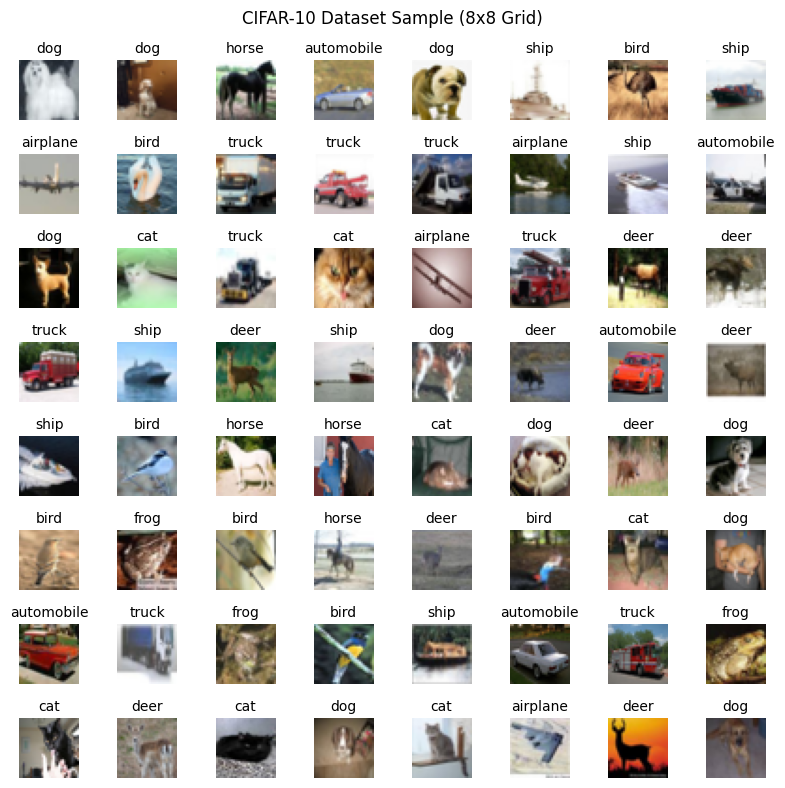

In [5]:
visualize_cifar10_grid(train_loader)

### Considerations for Dataset and Scalability

The subset of data which we chose to train is small and not proper to train a diffusion model. However, the focus here is to demonstrate how to use the TorchDiff API. You can scale up the training dataset or switch to more realistic, high-resolution, RGB images based on your specific needs.

## Training Process for the SDE Model

Before training a SDE, we need to prepare several key components required for the training process:

- **Noise Predictor ([torchdiff.utils.NoisePredictor](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor))**:
  This module predicts the amount of noise added to the data and uses this prediction to denoise the data during the backward pass of the diffusion process. For more details, refer to the [TorchDiff NoisePredictor documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor).

- **TextEncoder ([torchdiff.utils.TextEncoder](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder))**: Transformer-based encoder for text prompts or image labels in conditional diffusion models. For more details, refer to the [TorchDiff TextEncoder documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder). 

- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  For training the DDPM model, we use the AdamW optimizer, which is well-suited for optimizing neural networks.

- **Loss Function ([torch.nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))**:
  This tutorial employs a simple Mean Squared Error (MSE) loss from PyTorch, which computes the difference between the predicted noise (from the NoisePredictor) and the actual noise added during the forward pass.

- **Metrics ([torchdiff.utils.Metrics](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics))**:
  This class from the TorchDiff library computes various evaluation metrics based on the specified requirements. The following metrics are supported:
  - Fréchet Inception Distance (FID) (if `fid=True`).
  - Learned Perceptual Image Patch Similarity (LPIPS) (if `lpips=True`).
  - A set of three metrics: Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) (if `metrics=True`).
  For more details, refer to the [TorchDiff Metrics documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics).

In [7]:
# Initialize the NoisePredictor for the SDE model with parameters for RGB images
noise_predictor = NoisePredictor(
        in_channels=3,  # RGB images
        down_channels=[16, 32],
        mid_channels=[32, 32], 
        up_channels=[32, 16],
        down_sampling=[True, True],
        time_embed_dim=64,
        y_embed_dim=64,
        num_down_blocks=2,
        num_mid_blocks=2,
        num_up_blocks=2,
        down_sampling_factor=2
)

# label conditional model
text_encoder = TextEncoder(
        use_pretrained_model=True,
        model_name="bert-base-uncased",
        vocabulary_size=30522,
        num_layers=2,
        input_dimension=64,
        output_dimension=64,
        num_heads=2,
        context_length=77
)

# Set up the AdamW optimizer for the NoisePredictor parameters plus TextEncoder trainable parameters with a learning rate of 1e-3
optimizer = torch.optim.Adam(
    [p for p in noise_predictor.parameters() if p.requires_grad] +
    [p for p in text_encoder.parameters() if p.requires_grad], lr=1e-3
)

# Initialize the Mean Squared Error (MSE) loss function
loss = nn.MSELoss()

# Configure the Metrics class for evaluation on CPU (GPUs are recommended for actual training)
metrics = Metrics(
    device="cpu",  # Using CPU for this tutorial, but GPUs are recommended for training diffusion models
    fid=True, 
    metrics=True, 
    lpips_=True
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/loqman/Downloads/projs/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


### Required TorchDiff SDE Classes for Training

To train the DDIM model, this tutorial requires the following specific classes from the TorchDiff SDE module:

- **sde Hyperparameters ([HyperParamsSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.HyperParamsSDE))**:
  This class manages the noise schedule for the SDE model. For more details, refer to the [TorchDiff HyperParamsSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.HyperParamsSDE).

- **Reverse Diffusion ([ReverseSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ReverseSDE))**:
  This class is used during the sampling process to perform reverse diffusion. For more details, refer to the [TorchDiff ReverseSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ReverseSDE).

- **SDE Trainer ([TrainSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.TrainSDE))**:
  This class handles the training of the prepared SDE model. For more details, refer to the [TorchDiff TrainSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.TrainSDE).

In [8]:
# Initialize SDE hyperparameters for the noise schedule
hyperparams_sde = HyperParamsSDE(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02,
    sigma_start=1e-3, 
    sigma_end=10.0, 
    start=0.0,
    end=1.0, 
    beta_method="linear"
)

# Set up the reverse diffusion process for sampling
reverse_sde = ReverseSDE(
    hyper_params=hyperparams_sde, 
    method="vp" # there are three stochastic methods and one deterministic method available ("ve", "vp", "sub-vp", "ode"). Here we will use a stochastic method
)


# Configure the SDE trainer for model training
trainer = TrainSDE(
    method="ode", # "ve", "vp", "sub-vp", "ode"
    noise_predictor=noise_predictor,
    hyper_params=hyperparams_sde,
    conditional_model=text_encoder,
    metrics_=metrics,
    optimizer=optimizer,
    objective=loss,
    data_loader=train_loader,
    val_loader=val_loader,
    max_epoch=5,
    device="cpu",
    store_path="test_sde.pth",
    val_frequency=3
)

In [9]:
# start trining
train_losses, best_val_loss = trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:38<00:00,  5.53s/it]



Epoch: 1 | Train Loss: 1.3109


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:49<00:00,  7.07s/it]



Epoch: 2 | Train Loss: 1.2559


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:44<00:00,  6.34s/it]


...

 | Val Loss: 1.0620 | FID: 472.7205 | MSE: 0.1872 | PSNR: 7.2765 | SSIM: 0.0832 | LPIPS: 0.6996
Model saved at epoch 3


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:37<00:00,  5.39s/it]



Epoch: 4 | Train Loss: 1.1308


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:36<00:00,  5.20s/it]


Epoch: 5 | Train Loss: 1.0908


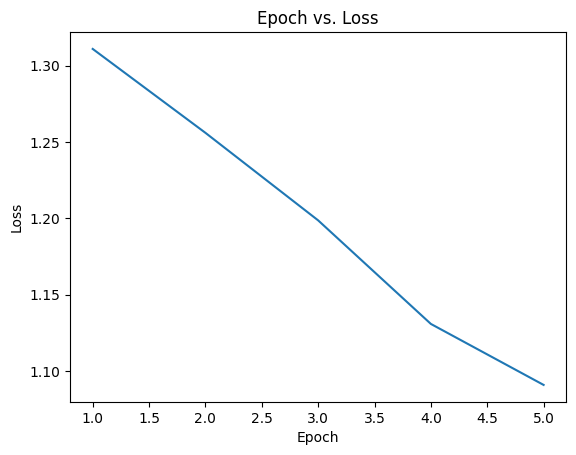

In [10]:
plt.plot([i for i in range(1, 6)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling Process for the SDE Model

After training the SDE model, we can generate new images. While we can directly use the trained model, it is common to load the trained parameters of the denoising model and generate new data using the [torchdiff.sde.SampleSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.SampleSDE) class. In this tutorial, we will load the trained parameters and generate new images.

In [14]:
# Initialize a new NoisePredictor with the same architecture as the trained model
new_noise_predictor = NoisePredictor(
    in_channels=3,  # RGB images
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=64,
    y_embed_dim=64,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# label conditional model
new_text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=2,
    input_dimension=64,
    output_dimension=64,
    num_heads=2,
    context_length=77
)

# Initialize DDIM hyperparameters for the noise schedule
new_hyperparams_sde = HyperParamsSDE(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02,
    sigma_start=1e-3, 
    sigma_end=10.0, 
    start=0.0,
    end=1.0, 
    beta_method="linear"
)

# Load the trained model checkpoint from file
checkpoint = torch.load('test_sde.pth', map_location='cpu')

# Load the trained parameters into the new NoisePredictor and set to evaluation mode
new_noise_predictor.load_state_dict(checkpoint['model_state_dict_noise_predictor'])
new_noise_predictor.eval()
# Print the total number of parameters in the NoisePredictor
print("Number of NoisePredictor's parameters:")
print(sum(p.numel() for p in new_noise_predictor.parameters()))

# Load the trained parameters into the new TextEncoder and set to evaluation mode
new_text_encoder.load_state_dict(checkpoint['model_state_dict_conditional'])
new_text_encoder.eval()
# Print the total  number of parameters in the NoisePredictor
print("Number of TextEncoder's parameters:")
print(sum(p.numel() for p in new_text_encoder.parameters()))



# Load the trained hyperparameters and set to evaluation mode
new_hyperparams_sde.load_state_dict(checkpoint['hyper_params_model'])
new_hyperparams_sde.eval() 
# Print the total number of parameters in the HyperParamsDDPM
print("Number of HyperParamsDDIM's parameters:")
print(sum(p.numel() for p in new_hyperparams_sde.parameters()))

# Set up the reverse diffusion process using the loaded hyperparameters
new_reverse_sde = ReverseSDE(new_hyperparams_sde, "vp")

Number of NoisePredictor's parameters:
177859
Number of TextEncoder's parameters:
109531456
Number of HyperParamsDDIM's parameters:
0


In [15]:
# sampling process
sampler = SampleSDE(
    reverse_diffusion=new_reverse_sde,
    noise_predictor=new_noise_predictor,
    image_shape=(32, 32),
    conditional_model=new_text_encoder,
    tokenizer="bert-base-uncased",
    max_length=77,
    batch_size=10,
    in_channels=3,
    device="cpu",
    output_range=(-1, 1)
)

In [16]:
gen_imgs = sampler(
    conditions=['airplane', 'automobile', 'bird', 'cat', 'deer', 
                'dog', 'frog', 'horse', 'ship', 'truck'], # 10 lables as conditions
    save_images=True,
    save_path="sde_generated"
) # the created images will be stored in the given directory

### Visualizing Generated Images

In this section, we will visualize the images generated by the trained SDE model to inspect the results of the sampling process.

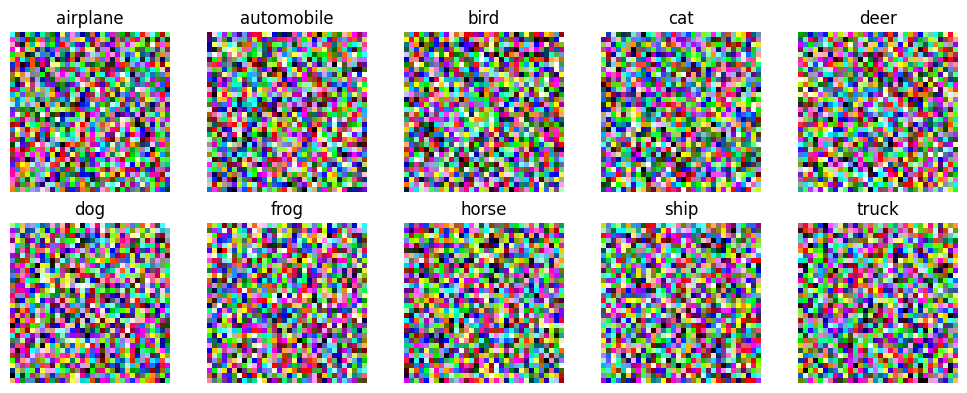

In [17]:
folder_path = "sde_generated"
conditions=['airplane', 'automobile', 'bird', 'cat', 'deer', 
            'dog', 'frog', 'horse', 'ship', 'truck']
num_images = 10 
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for i in range(num_images):
    img_path = os.path.join(folder_path, f"image_{i}.png")
    img = Image.open(img_path).convert('RGB') 

    ax = axes[i // cols, i % cols]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(conditions[i])

plt.tight_layout()
plt.show()

### Evaluating the Generated Images

The generated images may not be optimal, as we trained a shallow SDE model for only 10 epochs on a small subset of the CIFAR10 dataset. This limited training setup is intended to demonstrate the TorchDiff API rather than achieve high-quality results.

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Score-Based Generative Modeling with SDEs: Theory and Implementation in TorchDiff](https://medium.com/@samaniloqman91/score-based-generative-modeling-with-sdes-theory-and-implementation-in-torchdiff-db9a20a84978)
- [Score-Based Generative Modeling through Stochastic Differential Equations](https://arxiv.org/abs/2011.13456)